### **Imports**

In [84]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_iris
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

### **Task 1**

#### Created virtual environment (.venv)

### **Task 2**

In [85]:
iris_data = load_iris()
df = pd.DataFrame(data=iris_data.data, columns=iris_data.feature_names)

In [86]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [87]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### **Task 3**

In [88]:
titanic_data = pd.read_csv("data/titanic/train.csv")

In [89]:
titanic_data.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


#### Finding columns with missing values

In [90]:
columns_with_missing_values = titanic_data.columns[titanic_data.isna().any()]
display(columns_with_missing_values)

Index(['Age', 'Cabin', 'Embarked'], dtype='object')

#### Replacing missing values

In [91]:
# replacing missing age values using median, Embarked values using mode, and Cabin values as Unknown
titanic_data.fillna({
    'Age': titanic_data['Age'].median(), #median
    'Embarked': titanic_data['Embarked'].mode()[0], #most common outcome
    'Cabin': 'Unknown' #token
}, inplace=True)

In [92]:
titanic_data.isna().any()

PassengerId    False
Survived       False
Pclass         False
Name           False
Sex            False
Age            False
SibSp          False
Parch          False
Ticket         False
Fare           False
Cabin          False
Embarked       False
dtype: bool

### **Task 4**

#### One-Hot Encoding using Pandas

In [93]:
encoded_df = pd.get_dummies(titanic_data, columns=['Sex', 'Embarked'], drop_first=True)

In [94]:
encoded_df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,Unknown,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,Unknown,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,Unknown,True,False,True


#### One-Hot Encoding using Sklearn

In [95]:
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_array = encoder.fit_transform(titanic_data[['Sex', 'Embarked']])

# Transforming to a DataFrame
encoded_columns = encoder.get_feature_names_out(['Sex', 'Embarked'])
encoded_df = pd.DataFrame(encoded_array, columns=encoded_columns)

# Connect to the original DataFrame
titanic_encoded = pd.concat([
    titanic_data.drop(columns=['Sex', 'Embarked']),
    encoded_df], axis=1)

In [96]:
titanic_encoded.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,Unknown,1.0,0.0,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,0.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,Unknown,0.0,0.0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,0.0,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,Unknown,1.0,0.0,1.0


### **Task 5**

#### Standardization and normalization

In [97]:
df['species'] = pd.Categorical.from_codes(iris_data.target, iris_data.target_names)

# Select petal length and petal width
features = ['petal length (cm)', 'petal width (cm)']
X = df[features]
y = df['species']

# Standardized data
scaler_standard = StandardScaler()
X_standard = scaler_standard.fit_transform(X)

# Normalized data
scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X)

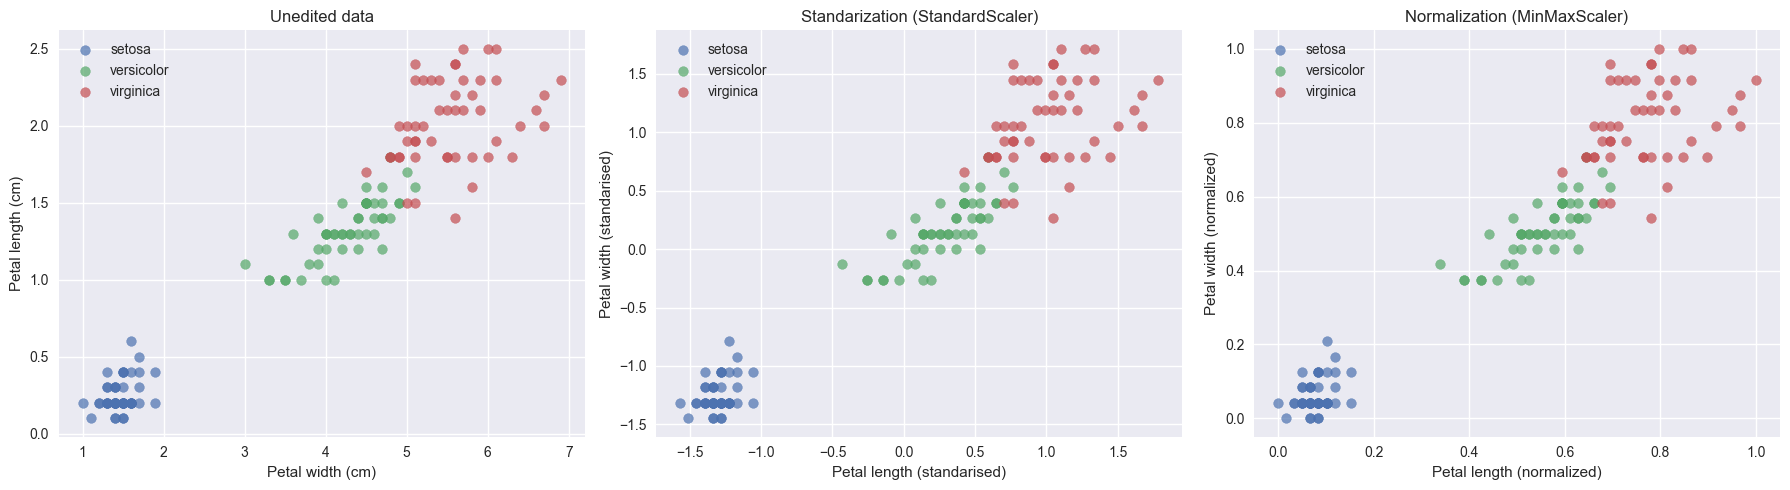

In [98]:
# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original data
for species in iris_data.target_names:
    axes[0].scatter(
        X[y == species][features[0]],
        X[y == species][features[1]],
        label=species,
        alpha=0.7
    )
axes[0].set_title('Unedited data')
axes[0].set_xlabel('Petal width (cm)')
axes[0].set_ylabel('Petal length (cm)')
axes[0].legend()

# Standardized data
for i, species in enumerate(iris_data.target_names):
    axes[1].scatter(
        X_standard[y == species, 0],
        X_standard[y == species, 1],
        label=species,
        alpha=0.7
    )
axes[1].set_title('Standarization (StandardScaler)')
axes[1].set_xlabel('Petal length (standarised)')
axes[1].set_ylabel('Petal width (standarised)')
axes[1].legend()

# Normalized data
for i, species in enumerate(iris_data.target_names):
    axes[2].scatter(
        X_minmax[y == species, 0],
        X_minmax[y == species, 1],
        label=species,
        alpha=0.7
    )
axes[2].set_title('Normalization (MinMaxScaler)')
axes[2].set_xlabel('Petal length (normalized)')
axes[2].set_ylabel('Petal width (normalized)')
axes[2].legend()


plt.style.use("seaborn-v0_8")
plt.tight_layout()

### **Task 6**

#### Splitting data

In [99]:
X = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
y = pd.Series(iris_data.target, name="target")

# Splitting data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [100]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (105, 4)
X_test shape: (45, 4)
y_train shape: (105,)
y_test shape: (45,)


### **Task 7 (revision)**

#### Loading data

In [101]:
titanic_df = pd.read_csv("data/titanic/train.csv")

In [102]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [103]:
titanic_df.info()
titanic_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### Managing missing values

In [104]:
columns_with_missing_values = titanic_df.columns[titanic_df.isna().any()]
display(columns_with_missing_values)

Index(['Age', 'Cabin', 'Embarked'], dtype='object')

##### a) Age

In [105]:
# Check how many missing values in Age
print("Missing Age values:", titanic_df['Age'].isnull().sum())

# Extract the non-missing Age values
age_non_missing = titanic_df['Age'].dropna()

# Impute missing Age values by random sampling from the observed distribution
titanic_df['Age'] = titanic_df['Age'].apply(
    lambda x: np.random.choice(age_non_missing) if pd.isnull(x) else x)

# Verify that no missing values remain
print("Missing Age values after imputation:", titanic_df['Age'].isnull().sum())

Missing Age values: 177
Missing Age values after imputation: 0


##### b) Embarked

In [106]:
# Check how many missing values in Embarked
print("Missing Embarked values:", titanic_df['Embarked'].isnull().sum())

# Calculate probabilities of each category
embarked_probs = titanic_df['Embarked'].value_counts(normalize=True)

# Fill missing values by sampling according to distribution
titanic_df['Embarked'] = titanic_df['Embarked'].apply(
    lambda x: np.random.choice(embarked_probs.index, p=embarked_probs.values) if pd.isnull(x) else x)

# Verify that no missing values remain
print("Missing Embarked values after imputation:", titanic_df['Embarked'].isnull().sum())

Missing Embarked values: 2
Missing Embarked values after imputation: 0


##### c) Cabin

In [107]:
# Check how many missing values in Cabin
print("Missing Cabin values:", titanic_df['Cabin'].isnull().sum())

# Fill missing values using "Unknown" token
titanic_df.fillna({
    'Cabin': 'Unknown'
}, inplace=True)

# Verify that no missing values remain
print("Missing Cabin values after imputation:", titanic_df['Cabin'].isnull().sum())

Missing Cabin values: 687
Missing Cabin values after imputation: 0


#### Processing of categorical data

In [108]:
encoded_titanic_df = pd.get_dummies(titanic_data, columns=['Sex', 'Embarked'], drop_first=True)

In [109]:
encoded_titanic_df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,Unknown,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,Unknown,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,Unknown,True,False,True


#### Scaling "Fare" column

In [110]:
# Initialize scaler
scaler = MinMaxScaler()
# Fit and transform the 'Fare' column
encoded_titanic_df['Fare'] = scaler.fit_transform(encoded_titanic_df[['Fare']])
# Quick check
print(encoded_titanic_df['Fare'].describe())

count    891.000000
mean       0.062858
std        0.096995
min        0.000000
25%        0.015440
50%        0.028213
75%        0.060508
max        1.000000
Name: Fare, dtype: float64


In [111]:
encoded_titanic_df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,0.014151,Unknown,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,0.139136,C85,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,0.015469,Unknown,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,0.103644,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,0.015713,Unknown,True,False,True


#### Saving modified data

In [112]:
encoded_titanic_df.to_csv("Modified_Titanic_Dataset", sep='\t', encoding='utf-8', index=False, header=True)